In [1]:
import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)


NumPy: 1.26.4
SciPy: 1.11.4


Basic Setup and Imports

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Set Local Dataset Path

In [23]:
# Set your dataset folder exactly as it is saved on your computer
dataset_path = r'C:\Users\hp\OneDrive\Desktop\BrainTumor\Tumour-20251221T093627Z-3-001.zip'
train_dir = os.path.join(dataset_path, 'train')
valid_dir = os.path.join(dataset_path, 'valid')
test_dir  = os.path.join(dataset_path, 'test')

In [4]:
import zipfile
import os

zip_path = r"C:\Users\hp\OneDrive\Desktop\BrainTumor\Tumour-20251221T093627Z-3-001.zip"
extract_path = r"C:\Users\hp\OneDrive\Desktop\BrainTumor"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction completed!")


✅ Extraction completed!


In [25]:
print(os.listdir(r"C:\Users\hp\OneDrive\Desktop\BrainTumor"))


['best_custom_cnn.h5', 'best_tl_model.h5', 'braintumor.ipynb', 'README.dataset.txt', 'test', 'tf_env', 'train', 'Tumour', 'Tumour-20251221T093627Z-3-001.zip', 'valid']


In [26]:
import os

train_dir = r"C:\Users\hp\OneDrive\Desktop\BrainTumor\train"
test_dir  = r"C:\Users\hp\OneDrive\Desktop\BrainTumor\test"
val_dir   = r"C:\Users\hp\OneDrive\Desktop\BrainTumor\valid"


In [27]:
print("Train exists:", os.path.exists(train_dir))
print("Test exists :", os.path.exists(test_dir))
print("Val exists  :", os.path.exists(val_dir))


Train exists: True
Test exists : True
Val exists  : True


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 20% for validation
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),#Standard size for ImageNet models
    batch_size=32,
    class_mode='categorical',
    subset='training'#80 percent of data for training
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'#20 percent of data for validation
)


Found 1358 images belonging to 4 classes.
Found 337 images belonging to 4 classes.


Preview Class Names and Sample Images

Tumor classes found: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


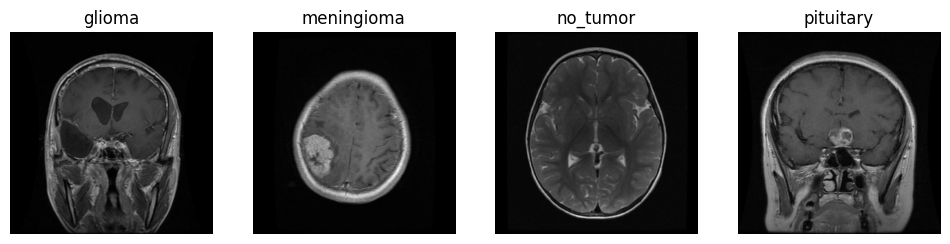

In [29]:
# Discover class folders (tumor types) under train
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Tumor classes found:", class_names)

# Preview one image per class
plt.figure(figsize=(12,6))
for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:
        img = plt.imread(os.path.join(class_folder, image_files[0]))
        plt.subplot(1, len(class_names), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')
plt.show()

Data Generators with Augmentation

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (224, 224)
batch_size = 32

# 🔹 Single generator with validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2   # ✅ 20% validation from training data
)

# 🔹 Training data
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 🔹 Validation data
valid_gen = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 🔹 Test data (NO augmentation, NO split)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 1358 images belonging to 4 classes.
Found 337 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


Step 5 : Model 1 – Custom CNN

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

custom_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])
custom_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
custom_model.summary()


c:\Users\hp\OneDrive\Desktop\BrainTumor\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

Training:

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
cnn_ckpt = ModelCheckpoint('best_custom_cnn.h5', save_best_only=True, monitor='val_loss', mode='min')

history_cnn = custom_model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    callbacks=[early_stop_cnn, cnn_ckpt]
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4402 - loss: 16.2725

43/43 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.4772 - loss: 7.6007 - val_accuracy: 0.2582 - val_loss: 51.1607
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.4374 - loss: 1.3337 - val_accuracy: 0.2582 - val_loss: 87.1157
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5199 - loss: 1.2244 - val_accuracy: 0.2582 - val_loss: 91.4768
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5000 - loss: 1.2261 - val_accuracy: 0.2582 - val_loss: 99.7905
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.4904 - loss: 1.2041 - val_accuracy: 0.2582 - val_loss: 73.0967
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4427 - loss: 1.1554

43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.4492 - loss: 1.1439 - val_accuracy: 0.2582 - val_loss: 41.5657
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4614 - loss: 1.1363

43/43 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.4514 - loss: 1.1189 - val_accuracy: 0.2582 - val_loss: 14.8766
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5687 - loss: 1.0058

43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.5589 - loss: 1.0250 - val_accuracy: 0.3620 - val_loss: 4.2390
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5092 - loss: 1.0435

43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5191 - loss: 1.0362 - val_accuracy: 0.4570 - val_loss: 1.8535
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5485 - loss: 0.9844

43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5633 - loss: 1.0276 - val_accuracy: 0.5045 - val_loss: 1.7877
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.5140 - loss: 1.0605 - val_accuracy: 0.5312 - val_loss: 2.1040
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5031 - loss: 1.0402

43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5022 - loss: 1.0737 - val_accuracy: 0.5193 - val_loss: 1.7271
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5140 - loss: 1.0156 - val_accuracy: 0.5460 - val_loss: 1.8672
Epoch 14/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5331 - loss: 1.0642 - val_accuracy: 0.5223 - val_loss: 2.0040
Epoch 15/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.5508 - loss: 0.9841 - val_accuracy: 0.4510 - val_loss: 3.3978
Epoch 16/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5875 - loss: 0.9656

43/43 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.5677 - loss: 1.0258 - val_accuracy: 0.5074 - val_loss: 1.4447
Epoch 17/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5623 - loss: 0.9563

43/43 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.5670 - loss: 0.9540 - val_accuracy: 0.5786 - val_loss: 1.1985
Epoch 18/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.5442 - loss: 1.0178 - val_accuracy: 0.5282 - val_loss: 1.4137
Epoch 19/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.5943 - loss: 0.9467 - val_accuracy: 0.6231 - val_loss: 1.6976
Epoch 20/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5825 - loss: 0.9807 - val_accuracy: 0.5193 - val_loss: 2.5248


Evaluation:

In [34]:
loss_cnn, acc_cnn = custom_model.evaluate(test_gen)
print(f"Custom CNN Test Acc: {acc_cnn:.4f} | Loss: {loss_cnn:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 407ms/step - accuracy: 0.6179 - loss: 0.8401
Custom CNN Test Acc: 0.6179 | Loss: 0.8401


Step 6 :  Model 2 – Transfer Learning (MobileNetV2)

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

tl_model = Model(base_model.input, output)
tl_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


Training:

In [36]:

early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
tl_ckpt = ModelCheckpoint('best_tl_model.h5', save_best_only=True, monitor='val_loss', mode='min')

history_tl = tl_model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    callbacks=[early_stop_tl, tl_ckpt]
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5657 - loss: 1.0979

43/43 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6937 - loss: 0.7665 - val_accuracy: 0.7240 - val_loss: 0.6337
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8140 - loss: 0.4854

43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8395 - loss: 0.4248 - val_accuracy: 0.7774 - val_loss: 0.5727
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8689 - loss: 0.3470 - val_accuracy: 0.7953 - val_loss: 0.6271
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8910 - loss: 0.2978 - val_accuracy: 0.8160 - val_loss: 0.6044
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8947 - loss: 0.2936 - val_accuracy: 0.7685 - val_loss: 0.6507
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8940 - loss: 0.2837 - val_accuracy: 0.7656 - val_loss: 0.6833
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9205 - loss: 0.2171 - val_accuracy: 0.7953 - val_loss: 0.6162


Evaluation:

In [37]:
loss_tl, acc_tl = tl_model.evaluate(test_gen)
print(f"MobileNetV2 Test Acc: {acc_tl:.4f} | Loss: {loss_tl:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7805 - loss: 0.5660
MobileNetV2 Test Acc: 0.7805 | Loss: 0.5660


Step 7 : Model Comparison

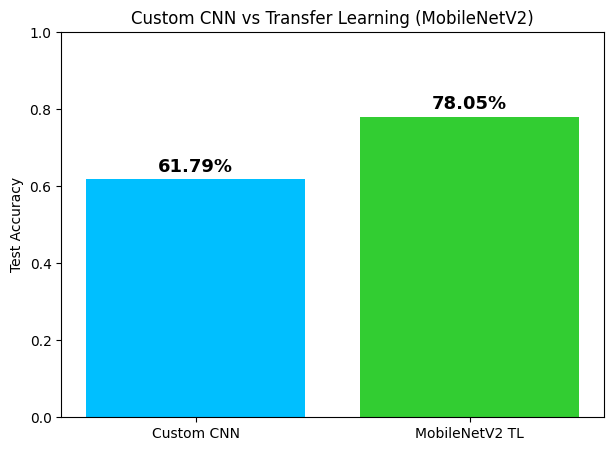

In [38]:
import matplotlib.pyplot as plt

models = ['Custom CNN', 'MobileNetV2 TL']
accuracies = [acc_cnn, acc_tl]

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracies, color=['deepskyblue', 'limegreen'])
plt.ylim([0, 1])
plt.ylabel("Test Accuracy")
plt.title("Custom CNN vs Transfer Learning (MobileNetV2)")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2%}",
             ha='center', va='bottom', fontweight='bold', fontsize=13)
plt.show()
